## Supplemental code for lesson 2

### Activating venv
```bash
# Linux and mac
source venv/bin/activate

# Windows --> use Git Bash shell
source venv/Scripts/activate

# If you plan to commit code to github --> add venv to .gitignore

# If you dont have the csv downloaded you can go to my github repo and download it
```

In [ ]:
# Strategy
Signal vs Noise:
- Signal is the true relationship between the features and the target
- Noise is the random variation in the data
- We want to find the signal and ignore the noise

Most teams follow - Industry EDA playbook:
1. Schema understanding
2. Target distribution
3.Univariate analysis
4.Missing data analysis
5.Bivariate analysis vs target
6.Correlation analysis
7.Feature engineering ideas
8.Hypothesis formulation
9.Modeling plan

Data size guide:
- < 1k rows --> very small
- 1k - 10k rows --> small
- 10k - 100k rows --> medium
- 100k - 1M rows --> large
- > 1M rows --> very large

Dataset size needs to be compared to model complexity:
- Simple models (linear regression) needs fewer samples to accurately predict
- Complex models (neural networks, deep learning) need many samples
- Medium datasets are the sweet spot
If dataset is too small compared to model complexity, model will overfit.

Trick:
- Train model with different sizes 10% - 20%, etc. see if performance plateaus
- Teach train/test split stability
- Cross validation variance
- Learning curves
Baselines help you answer the question:
- Is the model actually learning
- Is the dataset too small
- Is the dataset imbalanced

Plots depending on data types:
- Numerical features: histogram, boxplot, density plot
- Categorical features: count plot, bar plot
- Ordinal features: count plot, bar plot
- Date features: line plot
- Text features: word cloud
- Violin plot --> used for shape + density
- Heatmap --> used for correlation (highly correlated features may be redundant)
- Pairplot --> used for numerical features (often first visualization in industry to understand data)
- Pivot tables --> used for categorical features
Breakdown:
Distribution understanding
- Histogram
- KDE
- Boxplot
- Violin
Categorical comparison
- Countplot
- Barplot (aggregated target)
Relationship exploration
- Scatterplot
- Pairplot
Multivariate structure
- Correlation heatmap
- Pivot tables
Time structure (important to add)
- Line plots
- Rolling mean plots
Missing data visualization (add this!)
- Missing heatmap
- Bar chart of missing %

Skewed data:
- Log transformation --> used for right skewed data
- Square root transformation --> used for left skewed data
- Boxcox transformation --> used for both right and left skewed data
Why do models prefer normal distribution? --> linear models assume linear relationships
Many models perform better when features are:
    - symmetric
    - not heavy-tailed
    - not dominated by extreme outliers
    - Gradient-based optimization is more stable

How to determine if a feature is important or useless? --> use feature importance or correlation
- Combine family size feature (SibSp + Parch)
- Remove outliers (if they are not important, fraud detection, system failures, etc. want to predict outliers)
- Remove low variance features --> low variance features are usually useless
- Remove features that correlate with other features
- Use PCA to reduce dimensionality --> if features are highly correlated, and dimensionality is very high
Industry prefers:
- feature dropping
- regularization
- tree models

Some features may include leakage:
- Leaks the result --> causes overfit

Step 1: Dataset overview
- shape
- columns
- types
- memory usage
Check if datatypes make sense (ex: age should be an int not a float)
Categorical features should be object type, numerical features should be int or float
Is the dataset small or large? --> 891 passengers could risk overfitting (how to determine if dataset is large or small?)
Is the sample size representative of the population? --> how to check?
Is the sample size large enough to train a model? --> how to check?
Meaning of each column? --> list in real words

Target variable understanding: Survived
- Understand prediction difficulty
- Compute baseline accuracy --> survival rate (always compare model to naive baseline)
- Count plot of Survived
What is baseline accuracy good for?

Feature understanding (univariate analysis): Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
- Pclass --> distribution of passengers by class
- Count male vs female
- Age --> histogram or boxplot (children, vs adults, vs elderly)
- Gender --> is it skewed?
- SibSp --> distribution of siblings and spouses (family presence may predict survival)
- Parch --> distribution of parents and children (do children have a higher survival rate?)
- Fare --> histogram or boxplot (is it right skewed?) --> why? (log transformation)
- Embarked --> distribution of passengers by port of embarkation (is it skewed?)

Bivariate analysis: Pclass and Survived, Sex and Survived, Age and Survived, SibSp and Survived, Parch and Survived, Fare and Survived, Embarked and Survived
- Plot survival vs different features (ex: Pclass and Survived)
- See if there is a relationship between the feature and survival

Multivariate analysis: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked and Survived
- Understand interaction between multiple features
- Heatmaps, pivot tables, groupby, etc.
- Ex: Pclass and Sex and Survived

Data quality checks: Missing values, Duplicates, Outliers, Inconsistent values
- Missing values --> imputation, deletion, or use a model to predict
- Duplicates --> deletion
- Outliers --> deletion or imputation
- Inconsistent values --> standardization
- Extremely high values or impossible values --> ask students to theorize some impossible values

Feature engineering ideas:
- Combine features
- Create new features
- Remove features
- Standardize features
- Normalize features
- Bin features

Formulate a hypothesis:
- EDA is about asking questions about the data AND finding answers
- Ex: Pclass and Sex and Survived --> Women in first class have a higher survival rate.

Students must produce:
- Data summary report
- Key risks in dataset
- Feature engineering ideas
- Modeling hypotheses
- Evaluation plan


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMemory usage (bytes):")
print(df.memory_usage())

df.info()

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Memory usage (bytes):
Index           132
PassengerId    7128
Survived       7128
Pclass         7128
Name           7128
Sex            7128
Age            7128
SibSp          7128
Parch          7128
Ticket         7128
Fare           7128
Cabin          7128
Embarked       7128
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int

In [6]:
column_meanings = {
    "PassengerId": "Unique passenger identifier",
    "Survived": "Target variable: 0 = did not survive, 1 = survived",
    "Pclass": "Passenger class (1st, 2nd, 3rd)",
    "Name": "Passenger name",
    "Sex": "Passenger gender",
    "Age": "Passenger age",
    "SibSp": "Number of siblings/spouses aboard",
    "Parch": "Number of parents/children aboard",
    "Ticket": "Ticket number",
    "Fare": "Ticket fare paid",
    "Cabin": "Cabin number",
    "Embarked": "Port of embarkation (C, Q, S)"
}

pd.DataFrame(
    {"Column": list(column_meanings.keys()), "Meaning": list(column_meanings.values())}
)

,Column,Meaning
0,PassengerId,Unique passenger identifier
1,Survived,"Target variable: 0 = did not survive, 1 = surv..."
2,Pclass,"Passenger class (1st, 2nd, 3rd)"
3,Name,Passenger name
4,Sex,Passenger gender
5,Age,Passenger age
6,SibSp,Number of siblings/spouses aboard
7,Parch,Number of parents/children aboard
8,Ticket,Ticket number
9,Fare,Ticket fare paid


In [9]:
survival_counts = df["Survived"].value_counts()
survival_rate = df["Survived"].mean()

print("Survival counts:")
print(survival_counts)

print("\nSurvival rate:", round(survival_rate, 3))
print("Baseline accuracy if we always predict 'did not survive':", round(1 - survival_rate, 3))

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 0.384
Baseline accuracy if we always predict 'did not survive': 0.616


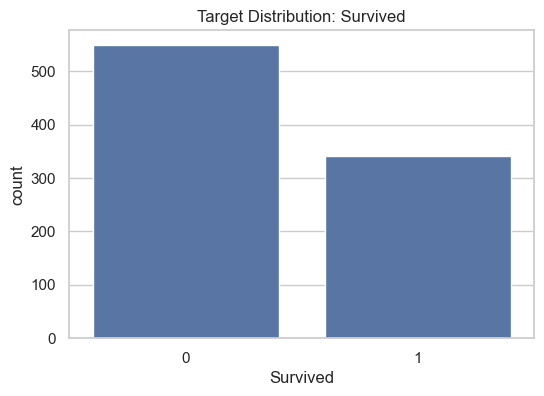

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Target Distribution: Survived")
plt.show()

In [11]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct
})

missing_df

,missing_count,missing_percent
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


# Univariate

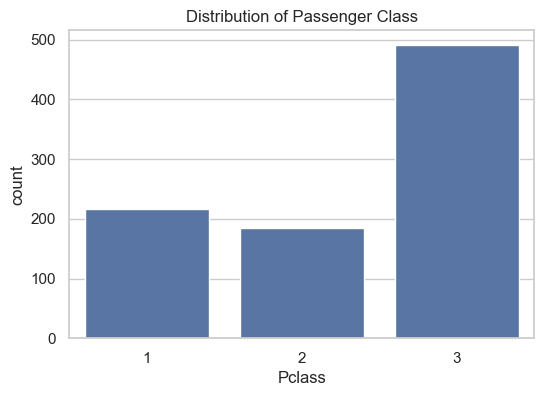

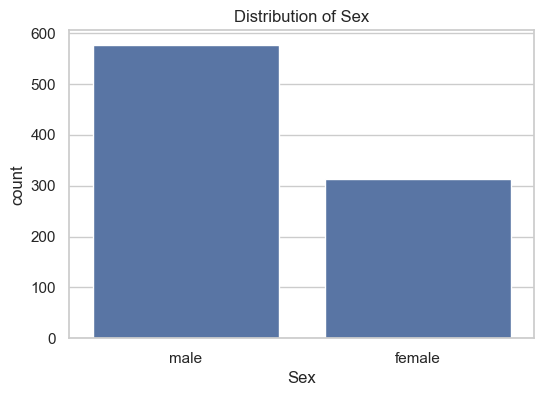

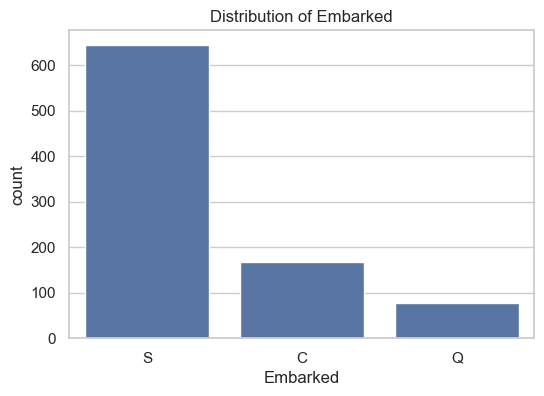

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass")
plt.title("Distribution of Passenger Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex")
plt.title("Distribution of Sex")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Embarked")
plt.title("Distribution of Embarked")
plt.show()

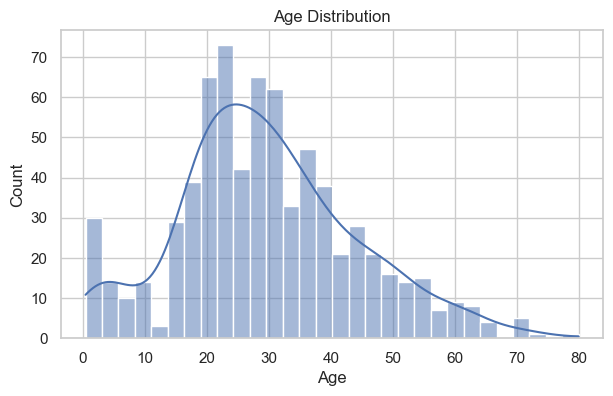

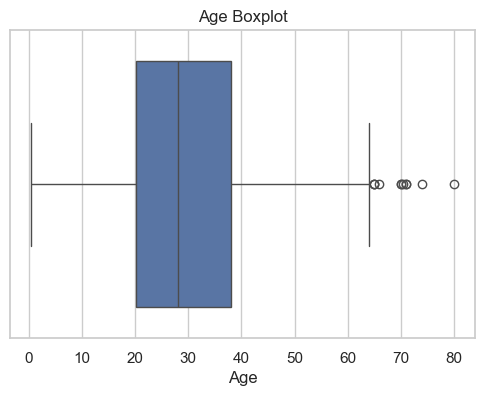

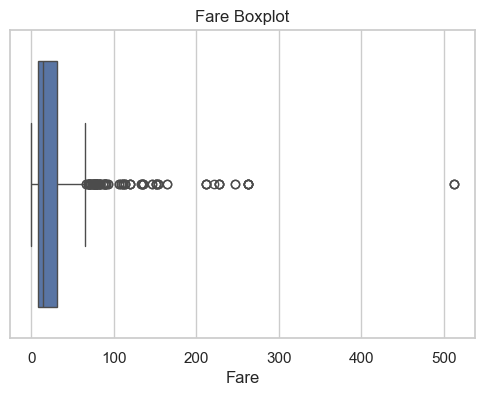

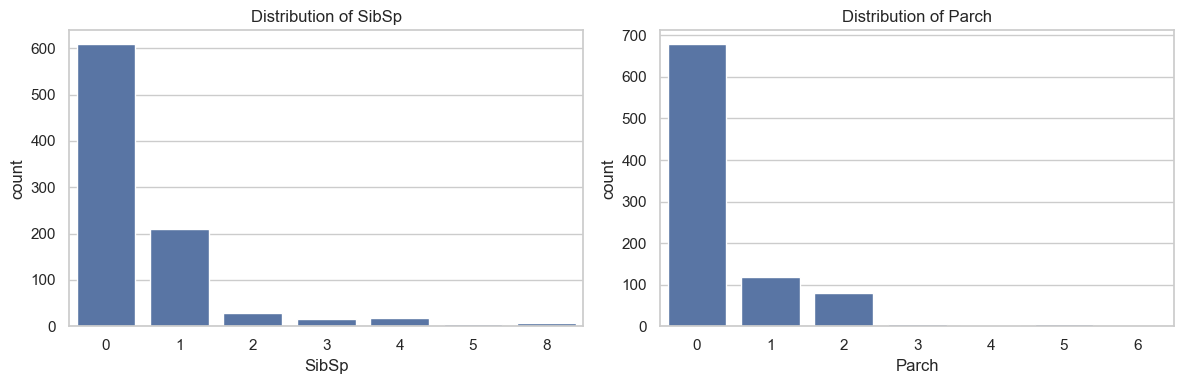

In [16]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="SibSp", ax=axes[0])
axes[0].set_title("Distribution of SibSp")

sns.countplot(data=df, x="Parch", ax=axes[1])
axes[1].set_title("Distribution of Parch")

plt.tight_layout()
plt.show()

In [17]:
print("Age skew:", df["Age"].skew())
print("Fare skew:", df["Fare"].skew())

Age skew: 0.38910778230082704
Fare skew: 4.787316519674893


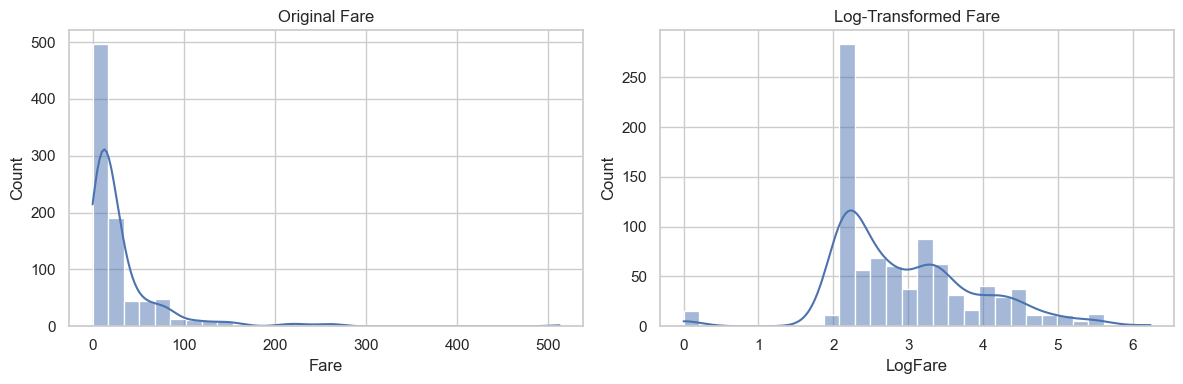

In [18]:
df["LogFare"] = np.log1p(df["Fare"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Fare")

sns.histplot(df["LogFare"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Fare")

plt.tight_layout()
plt.show()

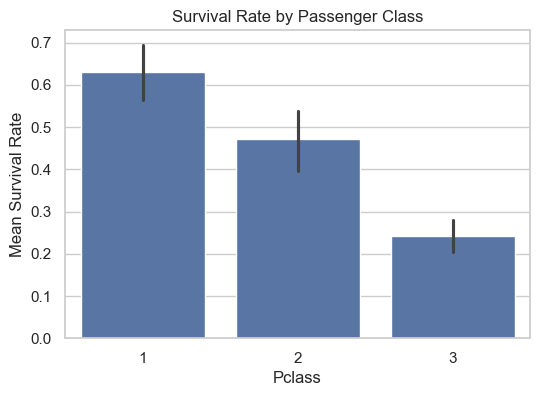

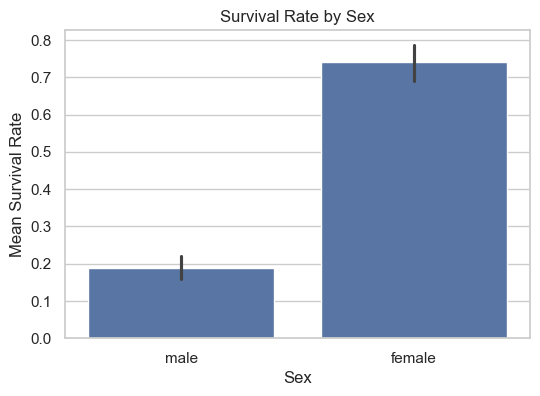

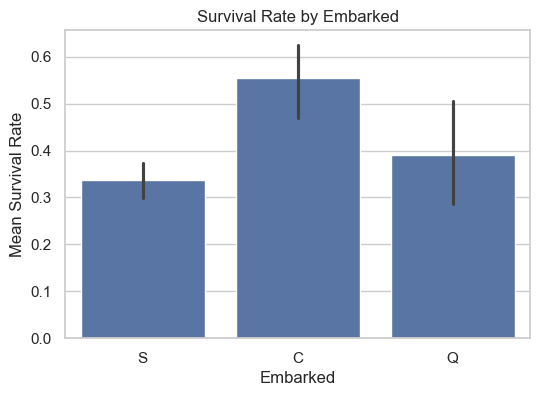

In [19]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Mean Survival Rate")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Mean Survival Rate")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Embarked", y="Survived")
plt.title("Survival Rate by Embarked")
plt.ylabel("Mean Survival Rate")
plt.show()

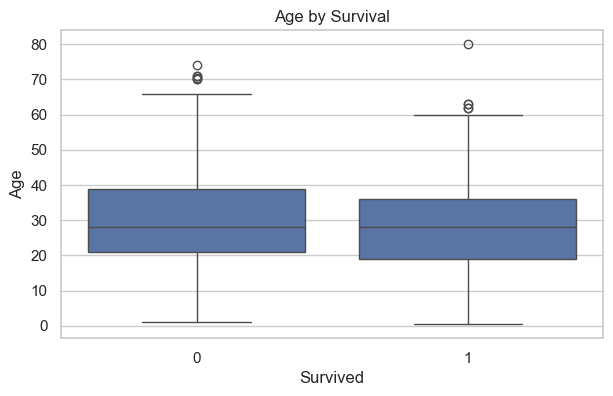

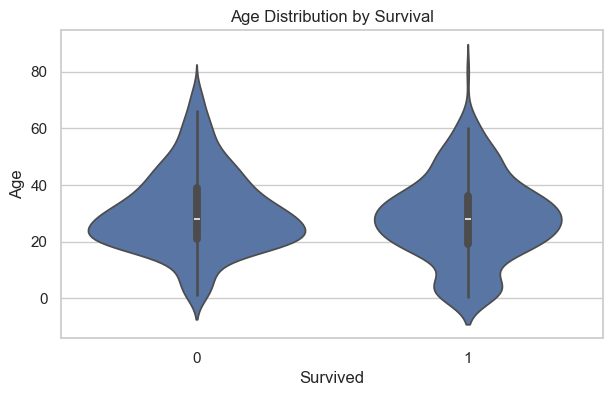

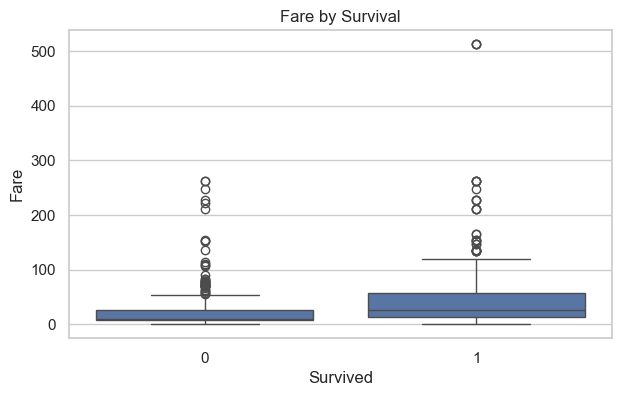

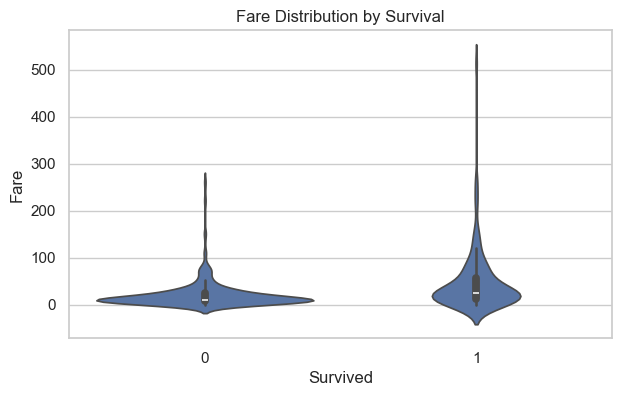

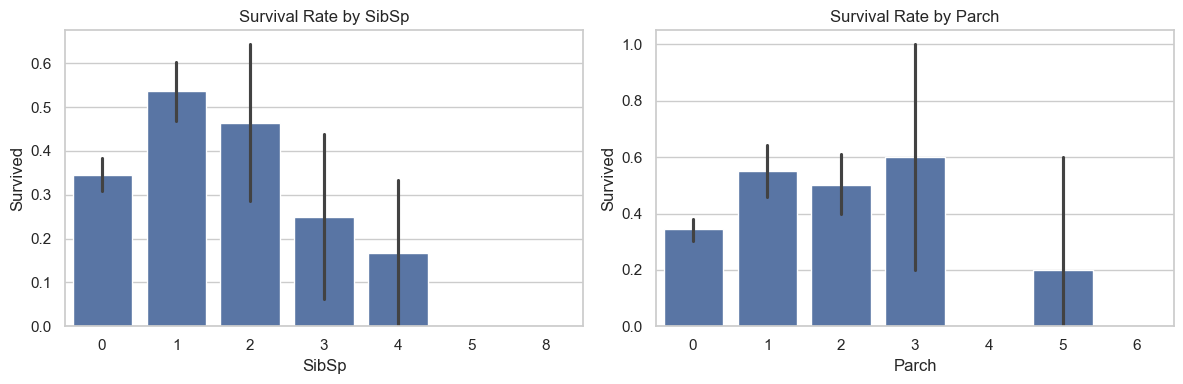

In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age by Survival")
plt.show()

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x="Survived", y="Age")
plt.title("Age Distribution by Survival")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare by Survival")
plt.show()

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="SibSp", y="Survived", ax=axes[0])
axes[0].set_title("Survival Rate by SibSp")

sns.barplot(data=df, x="Parch", y="Survived", ax=axes[1])
axes[1].set_title("Survival Rate by Parch")

plt.tight_layout()
plt.show()

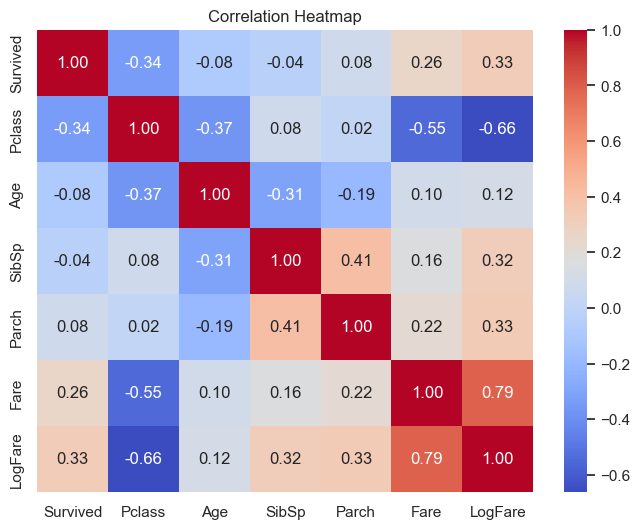

In [21]:
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "LogFare"]]

corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

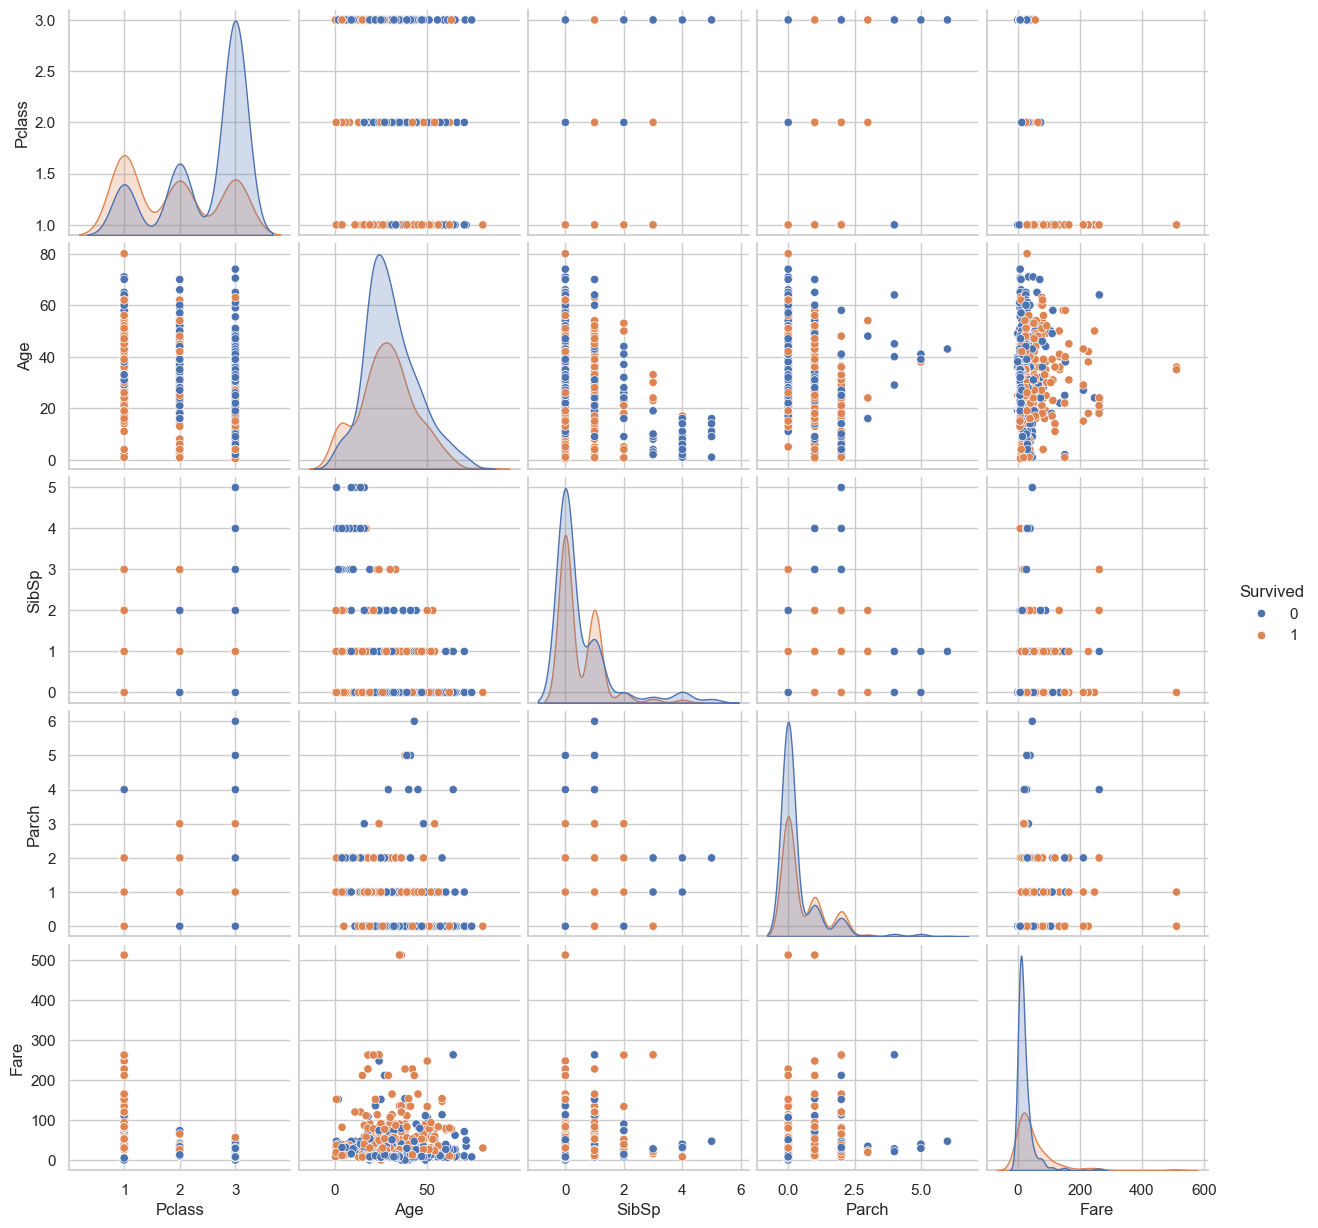

In [22]:
pairplot_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].dropna()

sns.pairplot(pairplot_df, hue="Survived")
plt.show()

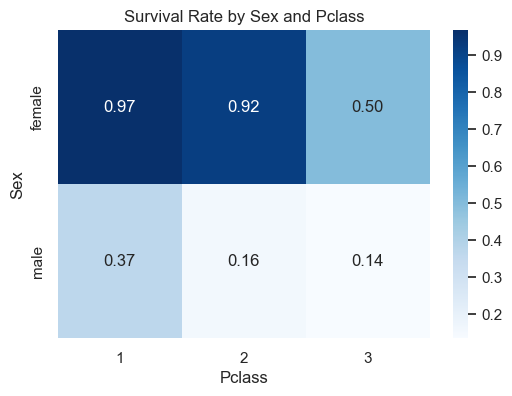

In [25]:
pivot_1 = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_1, annot=True, cmap="Blues", fmt=".2f")
plt.title("Survival Rate by Sex and Pclass")
plt.show()

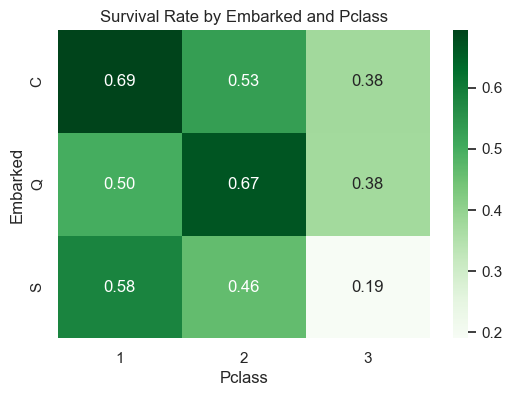

In [26]:
pivot_2 = df.pivot_table(values="Survived", index="Embarked", columns="Pclass", aggfunc="mean")
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_2, annot=True, cmap="Greens", fmt=".2f")
plt.title("Survival Rate by Embarked and Pclass")
plt.show()

# Quality checks

In [27]:
print("Duplicate rows:", df.duplicated().sum())

print("Negative fares:", (df["Fare"] < 0).sum())
print("Age below 0:", (df["Age"] < 0).sum())
print("Age above 100:", (df["Age"] > 100).sum())

print("Negative fares:", (df["Fare"] < 0).sum())
print("Age below 0:", (df["Age"] < 0).sum())
print("Age above 100:", (df["Age"] > 100).sum())

Duplicate rows: 0
Negative fares: 0
Age below 0: 0
Age above 100: 0
Negative fares: 0
Age below 0: 0
Age above 100: 0


In [28]:
numeric_variance = df[["Pclass", "Age", "SibSp", "Parch", "Fare"]].var()
numeric_variance

Pclass       0.699015
Age        211.019125
SibSp        1.216043
Parch        0.649728
Fare      2469.436846
dtype: float64

# Feature engineering ideas

In [29]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


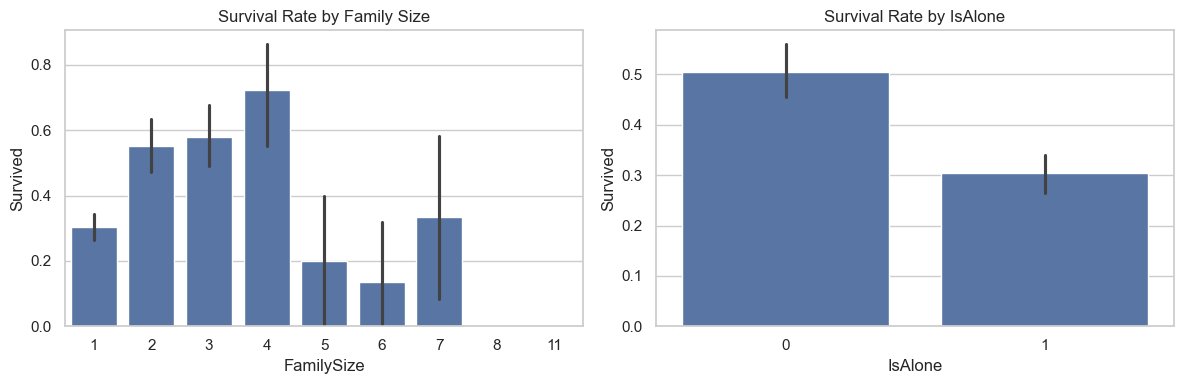

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="FamilySize", y="Survived", ax=axes[0])
axes[0].set_title("Survival Rate by Family Size")

sns.barplot(data=df, x="IsAlone", y="Survived", ax=axes[1])
axes[1].set_title("Survival Rate by IsAlone")

plt.tight_layout()
plt.show()

In [32]:
baseline_accuracy = max(df["Survived"].mean(), 1 - df["Survived"].mean())
print("Naive baseline accuracy:", round(baseline_accuracy, 3))

Naive baseline accuracy: 0.616


# Hypothesis Formulation

In [33]:
hypotheses = [
    "Women have a higher survival rate than men.",
    "First-class passengers have a higher survival rate than third-class passengers.",
    "Fare is positively associated with survival.",
    "Passengers traveling alone may have different survival rates than passengers with family.",
    "Interactions between Sex and Pclass are stronger than either feature alone."
]

for i, h in enumerate(hypotheses, start=1):
    print(f"{i}. {h}")

1. Women have a higher survival rate than men.
2. First-class passengers have a higher survival rate than third-class passengers.
3. Fare is positively associated with survival.
4. Passengers traveling alone may have different survival rates than passengers with family.
5. Interactions between Sex and Pclass are stronger than either feature alone.


In [34]:
deliverables = {
    "Data summary report": [
        "Titanic dataset has 891 rows and a mix of numeric and categorical features.",
        "Fare is strongly right-skewed.",
        "Age and Cabin contain missing values."
    ],
    "Key risks": [
        "Small dataset size may lead to overfitting for complex models.",
        "Missing values in Age and Cabin require treatment.",
        "Some features may need encoding or transformation."
    ],
    "Feature engineering ideas": [
        "FamilySize = SibSp + Parch + 1",
        "IsAlone indicator",
        "LogFare transformation"
    ],
    "Modeling hypotheses": [
        "Sex and Pclass will be among the strongest predictors.",
        "Interaction features may improve performance."
    ],
    "Evaluation plan": [
        "Compare against baseline accuracy.",
        "Use train/test split and cross-validation.",
        "Watch for overfitting due to small sample size."
    ]
}

deliverables


{'Data summary report': ['Titanic dataset has 891 rows and a mix of numeric and categorical features.',
  'Fare is strongly right-skewed.',
  'Age and Cabin contain missing values.'],
 'Key risks': ['Small dataset size may lead to overfitting for complex models.',
  'Missing values in Age and Cabin require treatment.',
  'Some features may need encoding or transformation.'],
 'Feature engineering ideas': ['FamilySize = SibSp + Parch + 1',
  'IsAlone indicator',
  'LogFare transformation'],
 'Modeling hypotheses': ['Sex and Pclass will be among the strongest predictors.',
  'Interaction features may improve performance.'],
 'Evaluation plan': ['Compare against baseline accuracy.',
  'Use train/test split and cross-validation.',
  'Watch for overfitting due to small sample size.']}